# Loan Prediction using Logistic Regression

Team Name:FOD-Team

Member name:Karun Rajbanshi

Roll no:ACE081BCT0351

## Problem Definition
The objective of this project is to predict whether a loan application will be approved or rejected based on applicant information such as income, loan amount, credit history, and property area.

## Model Choice
Logistic Regression is used because the target variable (Loan_Status) is binary, meaning it has two possible outcomes: Approved or Not Approved. Logistic regression is a widely used classification algorithm for such problems.

## Dataset Description

Dataset Name: Loan Prediction Dataset

Features:
- Gender
- Married
- Self_Employed
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History
- Education
- Dependents
- Property_Area

Target Variable:
Loan_Status (Approved or Not Approved)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
df = pd.read_csv("loan_data.csv")
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,Yes,9225,2355,116,360,1.0,Urban,Y
1,Female,Yes,2,Not Graduate,No,2026,4278,53,360,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,4724,4724,491,120,1.0,Urban,N
3,Male,No,0,Graduate,No,3375,2557,458,240,0.0,Urban,Y
4,Male,Yes,0,Graduate,No,3263,545,352,180,1.0,Semiurban,Y


In [3]:
print("Shape of dataset:", df.shape)
print("Columns:", df.columns)
df.info()
df.describe()

Shape of dataset: (500, 12)
Columns: Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             500 non-null    object 
 1   Married            500 non-null    object 
 2   Dependents         500 non-null    object 
 3   Education          500 non-null    object 
 4   Self_Employed      500 non-null    object 
 5   ApplicantIncome    500 non-null    int64  
 6   CoapplicantIncome  500 non-null    int64  
 7   LoanAmount         500 non-null    int64  
 8   Loan_Amount_Term   500 non-null    int64  
 9   Credit_History     500 non-null    float64
 10  Property_Area      500 non-null    object 
 

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,500.00000,500.000000,500.000000,500.000000,500.0000
mean,5718.11200,2417.254000,289.022000,227.280000,0.5200
std,2492.57919,1416.180491,133.568404,89.468491,0.5001
min,1501.00000,7.000000,50.000000,120.000000,0.0000
25%,3457.25000,1135.000000,172.500000,180.000000,0.0000
50%,5878.50000,2344.000000,300.500000,240.000000,1.0000
75%,7948.50000,3649.000000,406.000000,360.000000,1.0000
max,9967.00000,4998.000000,499.000000,360.000000,1.0000


In [4]:
numerical_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df['Income_per_Dependent'] = df['Total_Income'] / (df['Dependents'].replace('3+',3).astype(int) + 1)

df['Loan_to_Income'] = df['LoanAmount'] / df['Total_Income']

In [6]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Loan_Status'] = df_encoded['Loan_Status'].map({'Y':1,'N':0})

In [7]:
X = df_encoded.drop(['Loan_Status','ApplicantIncome','CoapplicantIncome'], axis=1)
y = df_encoded['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_hat):
    return -np.mean(y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9))

theta = np.zeros(X_train.shape[1])
learning_rate = 0.01
iterations = 1000
m = X_train.shape[0]
losses = []

for i in range(iterations):
    z = np.dot(X_train, theta)
    y_hat = sigmoid(z)
    gradient = np.dot(X_train.T, (y_hat - y_train)) / m
    theta -= learning_rate * gradient
    if i % 10 == 0:
        losses.append(compute_loss(y_train, y_hat))

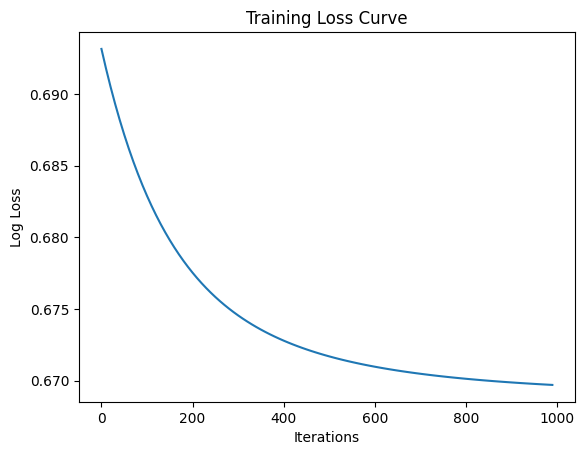

In [9]:
plt.plot(range(0,len(losses)*10,10), losses)
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Training Loss Curve")
plt.show()

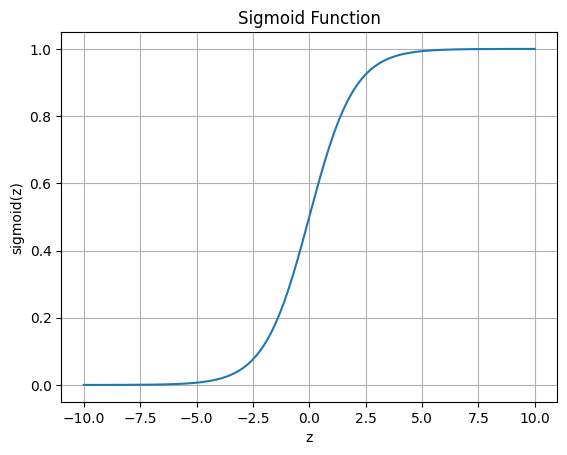

In [10]:
z_vals = np.linspace(-10,10,100)
sig_vals = sigmoid(z_vals)
plt.plot(z_vals, sig_vals)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

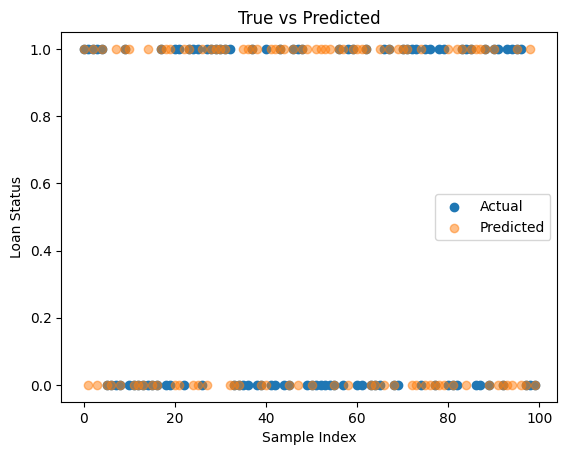

In [11]:
y_pred_prob = sigmoid(np.dot(X_test, theta))
y_pred = (y_pred_prob >= 0.5).astype(int)

plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.5)
plt.xlabel("Sample Index")
plt.ylabel("Loan Status")
plt.title("True vs Predicted")
plt.legend()
plt.show()

In [12]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1 Score:", round(f1,4))
print("ROC-AUC:", round(roc_auc,4))
print("Confusion Matrix:\n", cm)

Accuracy: 0.48
Precision: 0.463
Recall: 0.5208
F1 Score: 0.4902
ROC-AUC: 0.4816
Confusion Matrix:
 [[23 29]
 [23 25]]


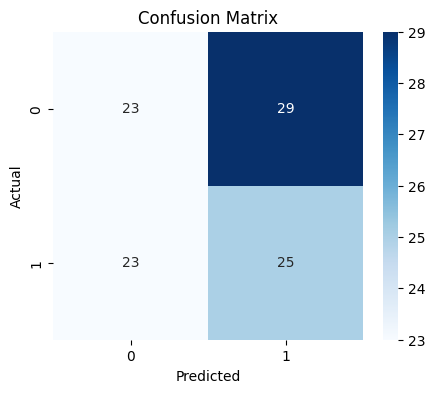

In [13]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
X_full = scaler.fit_transform(X)
y_full = y.values

theta_full = np.zeros(X_full.shape[1])
for i in range(iterations):
    z = np.dot(X_full, theta_full)
    y_hat_full = sigmoid(z)
    gradient = np.dot(X_full.T, (y_hat_full - y_full)) / len(y_full)
    theta_full -= learning_rate * gradient

final_loss = compute_loss(y_full, sigmoid(np.dot(X_full, theta_full)))
print("Final Log Loss on full dataset:", round(final_loss,4))

Final Log Loss on full dataset: 0.6763


## Conclusion

In this project, a logistic regression model was used to predict loan approval status based on applicant information such as income, loan amount, and credit history.After preprocessing the dataset and training the model, the performance was evaluated using accuracy, confusion matrix, precision, and recall.The results show that the model can reasonably predict whether a loan will be approved or rejected. Credit history and applicant income appear to play important roles in the prediction.This model demonstrates how machine learning can assist financial institutions in making faster and more consistent loan approval decisions.